In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime


In [79]:
data0 = pd.read_csv('complete_dataset.csv')
data1 = pd.read_csv('ExtraData/2017-2018.csv')
data2 = pd.read_csv('ExtraData/2018-2019.csv')
data3 = pd.read_csv('ExtraData/2019-2020.csv')
data4 = pd.read_csv('ExtraData/2020-2021.csv')
data5 = pd.read_csv('ExtraData/2021-2022.csv')
data6 = pd.read_csv('ExtraData/2022-2023.csv')
data7 = pd.read_csv('ExtraData/2023-2024.csv')
data = pd.concat([data0, data1, data2, data3, data4, data5, data6, data7], axis=0)
data.shape


(87117, 308)

In [80]:
def preprocess_data(data):
    data['Result'].fillna(method='ffill', inplace=True)
    data['Result'].unique()
    remove_columns = ['Cmp.1', 'Att.1', 'Cmp%.1', 'Cmp.2', 'Att.2', 'Cmp%.2', 'Cmp.3', 'Att.3', 'Cmp%.3', 'xAG', 'xA', 'CrsPA', 'PrgP',
                      'Live', 'Dead', 'FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Off', 'Blocks',
                      'SCA', 'PassDead', 'Def', 'GCA', 'PassDead.1', 'Def.1', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Tkl.1', 'Att', 'Tkl%',
                      'Lost', 'Blocks', 'Sh', 'Pass', 'Tkl+Int', 'Err', '2CrdY', 'Int', 'TklW',
                      'Recov', 'Won', 'Lost', 'Won%',
                      'SoTA', 'Save%', 'PKatt', 'PKA', 'PKsv', 'PKm', 'Cmp', 'Att', 'Cmp%',
                      'Att (GK)', 'Thr', 'Launch%', 'AvgLen', 'Att.1', 'Launch%.1', 'AvgLen.1', 'Opp', 'Stp', 'Stp%', '#OPA', 'AvgDist',
                      'O_Cmp.1', 'O_Att.1', 'O_Cmp%.1', 'O_Cmp.2', 'O_Att.2', 'O_Cmp%.2', 'O_Cmp.3', 'O_Att.3', 'O_Cmp%.3', 'O_xAG', 'O_xA', 'O_CrsPA', 'O_PrgP',
                      'Live', 'Dead', 'FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Off', 'Blocks',
                      'O_SCA', 'O_PassDead', 'O_Def', 'O_GCA', 'O_PassDead.1', 'O_Def.1', 'O_Def 3rd', 'O_Mid 3rd', 'O_Att 3rd', 'O_Tkl.1', 'O_Att', 'O_Tkl%',
                      'O_Lost', 'O_Blocks', 'O_Sh', 'O_Pass', 'O_Tkl+Int', 'O_Err', 'O_2CrdY', 'O_Int', 'O_TklW',
                      'O_Recov', 'O_Won', 'O_Lost', 'O_Won%',
                      'O_SoTA', 'O_Save%', 'O_PKatt', 'O_PKA', 'O_PKsv', 'O_PKm', 'O_Cmp', 'O_Att', 'O_Cmp%',
                      'O_Att (GK)', 'O_Thr', 'O_Launch%', 'O_AvgLen', 'O_Att.1', 'O_Launch%.1', 'O_AvgLen.1', 'O_Opp',
                      'O_Stp', 'O_Stp%', 'O_#OPA', 'O_AvgDist', 'Time', 'Round', 'GF', 'GA', 'G-xG', 'O_G-xG', 'np:G-xG',
                      'O_np:G-xG', 'GCA', 'O_GCA'
                      ]  # 144 columns
    data.drop(remove_columns, axis=1, inplace=True)
    percentage_columns = [x for x in data.columns if '%' in x]
    data.drop(percentage_columns, axis=1, inplace=True)
    is_null_sum_gt_20 = data.isnull().sum(axis=1) > 20  
    data = data[~is_null_sum_gt_20]
    data['Duplicate'] = data.groupby('Date')['Referee'].transform(lambda x: x.duplicated(keep='first'))
    data = data[~data['Duplicate']]
    data.drop(columns=['Duplicate'], inplace=True)
    print(f'The shape of the dataset must be (-1, 168) : {data.shape}')
    return data    


In [81]:
data['Result'].fillna(method='ffill', inplace=True)
data['Result'].unique()


array(['W', 'D', 'L'], dtype=object)

In [82]:
should_remove_Team = ['Cmp.1','Att.1','Cmp%.1','Cmp.2','Att.2','Cmp%.2','Cmp.3','Att.3','Cmp%.3', 'xAG','xA','CrsPA','PrgP',
                 'Live','Dead','FK','TB','Sw','Crs','TI','CK','In','Out','Str','Off','Blocks',
                 'SCA','PassDead','Def','GCA','PassDead.1','Def.1','Def 3rd','Mid 3rd','Att 3rd','Tkl.1','Att','Tkl%',
                 'Lost','Blocks','Sh','Pass','Tkl+Int','Err','2CrdY','Int','TklW',
                 'Recov','Won','Lost','Won%',
                 'SoTA','Save%','PKatt','PKA','PKsv','PKm','Cmp','Att','Cmp%',
                 'Att (GK)','Thr','Launch%','AvgLen','Att.1','Launch%.1','AvgLen.1','Opp','Stp','Stp%','#OPA','AvgDist'
                 ]
should_remove_Opponent = ['O_Cmp.1','O_Att.1','O_Cmp%.1','O_Cmp.2','O_Att.2','O_Cmp%.2','O_Cmp.3','O_Att.3','O_Cmp%.3', 'O_xAG','O_xA','O_CrsPA','O_PrgP',
                 'Live','Dead','FK','TB','Sw','Crs','TI','CK','In','Out','Str','Off','Blocks',
                 'O_SCA','O_PassDead','O_Def','O_GCA','O_PassDead.1','O_Def.1','O_Def 3rd','O_Mid 3rd','O_Att 3rd','O_Tkl.1','O_Att','O_Tkl%',
                 'O_Lost','O_Blocks','O_Sh','O_Pass','O_Tkl+Int','O_Err','O_2CrdY','O_Int','O_TklW',
                 'O_Recov','O_Won','O_Lost','O_Won%',
                 'O_SoTA','O_Save%','O_PKatt','O_PKA','O_PKsv','O_PKm','O_Cmp','O_Att','O_Cmp%',
                 'O_Att (GK)','O_Thr','O_Launch%','O_AvgLen','O_Att.1','O_Launch%.1','O_AvgLen.1','O_Opp',
                 'O_Stp','O_Stp%','O_#OPA','O_AvgDist'
                 
                 ]
remove_columns = ['Cmp.1','Att.1','Cmp%.1','Cmp.2','Att.2','Cmp%.2','Cmp.3','Att.3','Cmp%.3', 'xAG','xA','CrsPA','PrgP',
                 'Live','Dead','FK','TB','Sw','Crs','TI','CK','In','Out','Str','Off','Blocks',
                 'SCA','PassDead','Def','GCA','PassDead.1','Def.1','Def 3rd','Mid 3rd','Att 3rd','Tkl.1','Att','Tkl%',
                 'Lost','Blocks','Sh','Pass','Tkl+Int','Err','2CrdY','Int','TklW',
                 'Recov','Won','Lost','Won%',
                 'SoTA','Save%','PKatt','PKA','PKsv','PKm','Cmp','Att','Cmp%',
                 'Att (GK)','Thr','Launch%','AvgLen','Att.1','Launch%.1','AvgLen.1','Opp','Stp','Stp%','#OPA','AvgDist',
                 'O_Cmp.1','O_Att.1','O_Cmp%.1','O_Cmp.2','O_Att.2','O_Cmp%.2','O_Cmp.3','O_Att.3','O_Cmp%.3', 'O_xAG','O_xA','O_CrsPA','O_PrgP',
                 'Live','Dead','FK','TB','Sw','Crs','TI','CK','In','Out','Str','Off','Blocks',
                 'O_SCA','O_PassDead','O_Def','O_GCA','O_PassDead.1','O_Def.1','O_Def 3rd','O_Mid 3rd','O_Att 3rd','O_Tkl.1','O_Att','O_Tkl%',
                 'O_Lost','O_Blocks','O_Sh','O_Pass','O_Tkl+Int','O_Err','O_2CrdY','O_Int','O_TklW',
                 'O_Recov','O_Won','O_Lost','O_Won%',
                 'O_SoTA','O_Save%','O_PKatt','O_PKA','O_PKsv','O_PKm','O_Cmp','O_Att','O_Cmp%',
                 'O_Att (GK)','O_Thr','O_Launch%','O_AvgLen','O_Att.1','O_Launch%.1','O_AvgLen.1','O_Opp',
                 'O_Stp','O_Stp%','O_#OPA','O_AvgDist', 'Time', 'Round', 'GF', 'GA', 'G-xG', 'O_G-xG', 'np:G-xG',
                 'O_np:G-xG', 'GCA', 'O_GCA', 'Formation'       
                 ] # 145 columns


In [83]:
data.drop(remove_columns, axis=1, inplace=True)
data.shape


(87117, 175)

In [84]:
percentage_columns = [x for x in data.columns if '%' in x]
data.drop(percentage_columns, axis=1, inplace=True)
data.shape


(87117, 167)

In [85]:
is_null_sum_gt_20 = data.isnull().sum(axis=1) > 20  
data = data[~is_null_sum_gt_20]
data.shape


(75188, 167)

In [86]:
data.tail()


,Date,Comp,Day,Venue,Result,Team,Opponent,xG,xGA,Poss,...,O_Fls,O_Fld.2,O_Off.1,O_Crs.1,O_Int.1,O_TklW.1,O_PKwon,O_PKcon,O_OG,O_Lost.1
6059,2023-11-09,Conf Lg,Thu,Home,W,Viktoria Plzeň,hr Dinamo Zagreb,2.4,0.6,36.0,...,6.0,22.0,3.0,28.0,10.0,6.0,0.0,1.0,0.0,21.0
6062,2023-11-30,Conf Lg,Thu,Away,W,Viktoria Plzeň,xk KF Ballkani Therandë,1.6,0.6,42.0,...,8.0,22.0,2.0,17.0,12.0,16.0,0.0,0.0,0.0,23.0
6065,2023-12-14,Conf Lg,Thu,Home,W,Viktoria Plzeň,kz Astana FK,3.4,0.4,63.0,...,10.0,17.0,2.0,11.0,12.0,7.0,0.0,0.0,0.0,18.0
6072,2024-03-07,Conf Lg,Thu,Away,D,Viktoria Plzeň,ch Servette FC,0.2,0.6,52.0,...,18.0,16.0,4.0,17.0,14.0,8.0,0.0,0.0,0.0,38.0
6074,2024-03-14,Conf Lg,Thu,Home,D,Viktoria Plzeň,ch Servette FC,1.3,1.5,49.0,...,14.0,13.0,1.0,29.0,3.0,10.0,0.0,0.0,0.0,46.0


In [87]:
# correlation_matrix = data.corr(numeric_only=True)
# high_correlation_features = []
# for i in range(len(correlation_matrix.columns)):
#     for j in range(i + 1, len(correlation_matrix.columns)):
#         if abs(correlation_matrix.iloc[i, j]) > 0.9:
#             high_correlation_features.append((correlation_matrix.columns[i], correlation_matrix.columns[j]))

# for feature1, feature2 in high_correlation_features:
#     if feature2 in data.columns:
#         data.drop(feature2, axis=1, inplace=True)

# print(data.shape)


In [88]:
data['Duplicate'] = data.groupby('Date')['Referee'].transform(lambda x: x.duplicated(keep='first'))
data = data[~data['Duplicate']]
data.drop(columns=['Duplicate'], inplace=True)
print(data.shape)

# This is just for testing purposes
# grouped = data.groupby('Date')
# for date, group in grouped:
    
#     print(f'For Date {date}')   
#     a = list(group["Team"])
#     b = list(group["Opponent"])
#     print(a)
#     print(b)
#     print('*' * 50)    


(32537, 167)


In [89]:
data.head()


,Date,Comp,Day,Venue,Result,Team,Opponent,xG,xGA,Poss,...,O_Fls,O_Fld.2,O_Off.1,O_Crs.1,O_Int.1,O_TklW.1,O_PKwon,O_PKcon,O_OG,O_Lost.1
0,2017-08-12,Premier League,Sat,Away,W,Manchester City,Brighton,1.9,0.3,77.0,...,6.0,8.0,6.0,8.0,12.0,8.0,0.0,0.0,1.0,13.0
1,2017-08-21,Premier League,Mon,Home,D,Manchester City,Everton,1.1,0.6,64.0,...,9.0,7.0,3.0,9.0,16.0,12.0,0.0,0.0,0.0,22.0
2,2017-08-26,Premier League,Sat,Away,W,Manchester City,Bournemouth,1.4,0.5,70.0,...,13.0,14.0,0.0,9.0,12.0,13.0,0.0,0.0,0.0,23.0
3,2017-09-09,Premier League,Sat,Home,W,Manchester City,Liverpool,2.4,0.7,66.0,...,9.0,10.0,2.0,9.0,18.0,12.0,0.0,0.0,0.0,9.0
4,2017-09-13,Champions Lg,Wed,Away,W,Manchester City,nl Feyenoord,1.3,0.3,71.0,...,14.0,9.0,3.0,8.0,13.0,9.0,0.0,0.0,0.0,14.0


In [90]:
# data['MatchID'] = None
# for i, row in data.iterrows():
#     matches = []
#     team = row['Team']
#     opponent = row['Opponent']
#     matches.append(team)
#     matches.append(opponent)
#     matches.sort()
#     data.loc[i, 'MatchID'] = '#' + str(matches[0]) + str(matches[1])

# data.head()


In [91]:
unused_cols = ['G/Sh', 'G/SoT', 'Dist', 'PK', 'xG', 'npxG', 'npxG/Sh', 'PSxG', 'PSxG+/-', 'PKatt.1', 'TotDist', 'PrgDist', 'Att.1.1',  'KP', '1/3', 'PPA',  'Att.5', 'FK.1', 'Cmp.5', 'PassLive', 'TO', 'Sh.2', 'Fld', 'PassLive.1', 'TO.1', 'Sh.1', 'Fld.1', 'Tkl', 'Att.6', 'Blocks.1', 'Sh.3', 'Clr', 'Poss.1', 'Touches', 'Def Pen', 'Def 3rd.1', 'Mid 3rd.1', 'Att 3rd.1', 'Att Pen', 'Live.1', 'Att.7', 'Succ', 'Tkld', 'Carries', 'TotDist.1', 'PrgDist.1', 'PrgC', '1/3.1', 'Mis', 'Dis', 'Rec', 'PrgR', 'Fld.2', 'Int.1', 'TklW.1', 'OG', 'Lost.1']

aunused_cols = []
for co in unused_cols:
     if co =='Poss.1':
          continue
     conew = 'O_' + co
     aunused_cols.append(conew)
unused_cols.extend(aunused_cols)
data.drop(unused_cols, axis=1, inplace=True)
data.shape


(32537, 54)

In [92]:
for index, row in data.iterrows():
    if row['Venue'] == 'Home' and row['Result'] == 'W':
        data.loc[index, 'Result'] = 'H'
    elif row['Venue'] == 'Home' and row['Result'] == 'L':
        data.loc[index, 'Result'] = 'A'
    elif row['Venue'] == 'Away' and row['Result'] == 'W':
        data.loc[index, 'Result'] = 'A'
    elif row['Venue'] == 'Away' and row['Result'] == 'L':
        data.loc[index, 'Result'] = 'H'
    else:
        data.loc[index, 'Result'] = 'D'

data['FTR'] = np.where(data['Result'] == 'H', 0, np.where(

    data['Result'] == 'D', 1, np.where(data['Result'] == 'A', 2, np.nan)))

data.drop('Result', axis=1, inplace=True)


In [93]:
data['Date'] = pd.to_datetime(data['Date'])


def get_weights(data):
    now = datetime.datetime.now()
    weight = 1.0 / (1 + (now - data['Date']).dt.days / 365)
    return weight


data['weight'] = get_weights(data)
data.drop(['Date', 'Captain'], axis=1, inplace=True)
data.head()


,Comp,Day,Venue,Team,Opponent,xGA,Poss,Attendance,Referee,SoT,...,O_CPA,O_CrdY,O_CrdR,O_Fls,O_Off.1,O_Crs.1,O_PKwon,O_PKcon,FTR,weight
0,Premier League,Sat,Away,Manchester City,Brighton,0.3,77.0,30415.0,Michael Oliver,4.0,...,1.0,0.0,0.0,6.0,6.0,8.0,0.0,0.0,0.0,0.131153
1,Premier League,Mon,Home,Manchester City,Everton,0.6,64.0,49108.0,Robert Madley,6.0,...,1.0,4.0,1.0,9.0,3.0,9.0,0.0,0.0,0.0,0.131579
2,Premier League,Sat,Away,Manchester City,Bournemouth,0.5,70.0,10419.0,Mike Dean,8.0,...,0.0,5.0,0.0,13.0,0.0,9.0,0.0,0.0,1.0,0.131817
3,Premier League,Sat,Home,Manchester City,Liverpool,0.7,66.0,54172.0,Jonathan Moss,10.0,...,6.0,2.0,1.0,9.0,2.0,9.0,0.0,0.0,0.0,0.132486
4,Champions Lg,Wed,Away,Manchester City,nl Feyenoord,0.3,71.0,43500.0,Szymon Marciniak,7.0,...,1.0,4.0,0.0,14.0,3.0,8.0,0.0,0.0,2.0,0.132679


In [94]:
data.isna().sum()


Comp             0
Day              0
Venue            0
Team             0
Opponent         0
xGA            115
Poss            72
Attendance    8338
Referee         55
SoT              0
xG.1             0
Saves            4
CS               6
Cmp.4            0
Att.4            0
Ast              0
CPA              0
CrdY             0
CrdR             0
Fls              0
Off.1            0
Crs.1            0
PKwon            0
PKcon            0
O_SoT            0
O_FK             0
O_Saves          3
O_CS             6
O_Cmp.4          0
O_Att.4          0
O_Ast            0
O_Live           0
O_Dead           0
O_TB             0
O_Sw             0
O_Crs            0
O_TI             0
O_CK             0
O_In             0
O_Out            0
O_Str            0
O_Off            0
O_Poss           1
O_CPA            0
O_CrdY           0
O_CrdR           0
O_Fls            0
O_Off.1          0
O_Crs.1          0
O_PKwon          0
O_PKcon          0
FTR              0
weight      

In [95]:
data['Attendance'].fillna(np.mean(data['Attendance']), inplace=True)
data['xGA'].fillna(np.mean(data['xGA']), inplace=True)
data['Referee'].fillna(value='bfill', inplace=True)
data['Poss'].fillna(np.mean(data['Poss']), inplace=True)
data['Saves'].fillna(np.mean(data['Saves']), inplace=True)
data['O_Saves'].fillna(np.mean(data['O_Saves']), inplace=True)
data['O_CS'].fillna(np.mean(data['O_CS']), inplace=True)
data['CS'].fillna(np.mean(data['CS']), inplace=True)
data['O_Poss'].fillna(np.mean(data['O_Poss']), inplace=True)

data.isna().sum()


Comp          0
Day           0
Venue         0
Team          0
Opponent      0
xGA           0
Poss          0
Attendance    0
Referee       0
SoT           0
xG.1          0
Saves         0
CS            0
Cmp.4         0
Att.4         0
Ast           0
CPA           0
CrdY          0
CrdR          0
Fls           0
Off.1         0
Crs.1         0
PKwon         0
PKcon         0
O_SoT         0
O_FK          0
O_Saves       0
O_CS          0
O_Cmp.4       0
O_Att.4       0
O_Ast         0
O_Live        0
O_Dead        0
O_TB          0
O_Sw          0
O_Crs         0
O_TI          0
O_CK          0
O_In          0
O_Out         0
O_Str         0
O_Off         0
O_Poss        0
O_CPA         0
O_CrdY        0
O_CrdR        0
O_Fls         0
O_Off.1       0
O_Crs.1       0
O_PKwon       0
O_PKcon       0
FTR           0
weight        0
dtype: int64

In [96]:
comp_labels = {
    '2. Bundesliga': 1, 'A-League': 2, 'Bundesliga': 3, 'Champions Lg': 4,
    'Conf Lg': 5, 'Copa de la Liga Profesional': 6, 'Copa del Rey': 7,
    'Coppa Italia': 8, 'Coupe de France': 9, 'Coupe de la Ligue': 10, 'D1 Fém': 11,
    'DFB-Pokal': 12, 'EFL Cup': 13, 'Eredivisie': 14, 'Europa Lg': 15, 'FA Cup': 16,
    'First Division A': 17, 'La Liga': 18, 'Libertadores': 19, 'Liga F': 20, 'Liga MX': 21,
    'Ligue 1': 22, 'Ligue 2': 23, 'Premier League': 24, 'Premiership': 25,
    'Primeira Liga': 26, 'Primera Div': 27, 'Pro League A': 28, 'Serie A': 29,
    'Serie B': 30, 'Série A': 31, 'W-League': 32, 'WSL': 33
}
unique_teams = data['Team'].unique()
team_labels = {team: label for label, team in enumerate(unique_teams)}

unique_Opponent = data['Opponent'].unique()
opponent_labels = {team: label for label, team in enumerate(unique_Opponent)}

unique_referee = data['Referee'].unique()
referee_labels = {referee: label for label,
                  referee in enumerate(unique_referee)}

unique_day = data['Day'].unique()
day_labels = {day: label for label, day in enumerate(unique_day)}

data['Comp'] = data['Comp'].replace(comp_labels)
data['Team'] = data['Team'].replace(team_labels)
data['Opponent'] = data['Opponent'].replace(opponent_labels)
data['Referee'] = data['Referee'].replace(referee_labels)
data['Day'] = data['Day'].replace(day_labels)
data['Venue'] = data['Venue'].replace({'Home': 0, 'Away': 1, 'Neutral': 2})


In [97]:
data.head()


,Comp,Day,Venue,Team,Opponent,xGA,Poss,Attendance,Referee,SoT,...,O_CPA,O_CrdY,O_CrdR,O_Fls,O_Off.1,O_Crs.1,O_PKwon,O_PKcon,FTR,weight
0,24,0,1,0,0,0.3,77.0,30415.0,0,4.0,...,1.0,0.0,0.0,6.0,6.0,8.0,0.0,0.0,0.0,0.131153
1,24,1,0,0,1,0.6,64.0,49108.0,1,6.0,...,1.0,4.0,1.0,9.0,3.0,9.0,0.0,0.0,0.0,0.131579
2,24,0,1,0,2,0.5,70.0,10419.0,2,8.0,...,0.0,5.0,0.0,13.0,0.0,9.0,0.0,0.0,1.0,0.131817
3,24,0,0,0,3,0.7,66.0,54172.0,3,10.0,...,6.0,2.0,1.0,9.0,2.0,9.0,0.0,0.0,0.0,0.132486
4,4,2,1,0,4,0.3,71.0,43500.0,4,7.0,...,1.0,4.0,0.0,14.0,3.0,8.0,0.0,0.0,2.0,0.132679


In [98]:
data.describe()


,Comp,Day,Venue,Team,Opponent,xGA,Poss,Attendance,Referee,SoT,...,O_CPA,O_CrdY,O_CrdR,O_Fls,O_Off.1,O_Crs.1,O_PKwon,O_PKcon,FTR,weight
count,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,...,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000
mean,18.861604,2.545717,0.502474,135.935673,277.287672,1.091790,54.455660,21631.565891,329.162738,4.844177,...,3.234349,2.171835,0.121431,12.743676,1.778529,16.759812,0.099794,0.187817,0.875803,0.340680
std,9.296766,2.175146,0.504225,106.560517,198.507482,0.663712,9.712315,15760.894468,275.808669,2.585803,...,2.245601,1.440273,0.350507,4.187450,1.576370,7.685762,0.316489,0.426964,0.860527,0.201820
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,11.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.130450
25%,14.000000,0.000000,0.000000,47.000000,109.000000,0.600000,48.000000,10308.000000,109.000000,3.000000,...,2.000000,1.000000,0.000000,10.000000,1.000000,11.000000,0.000000,0.000000,0.000000,0.182591
50%,22.000000,3.000000,1.000000,103.000000,230.000000,1.000000,55.000000,21631.565891,240.000000,5.000000,...,3.000000,2.000000,0.000000,12.000000,1.000000,16.000000,0.000000,0.000000,1.000000,0.278201
75%,26.000000,4.000000,1.000000,219.000000,475.000000,1.500000,61.000000,24915.000000,549.000000,6.000000,...,4.000000,3.000000,0.000000,15.000000,3.000000,21.000000,0.000000,0.000000,2.000000,0.429412
max,33.000000,6.000000,2.000000,398.000000,672.000000,6.000000,85.000000,180707.000000,1031.000000,22.000000,...,20.000000,10.000000,3.000000,34.000000,15.000000,63.000000,3.000000,3.000000,2.000000,0.973333


In [ ]:
for col in data.columns:
    plt.figure(figsize=(10, 4))  # Adjust figure size as needed
    plt.boxplot(data[col], vert=False, showfliers=True)
    plt.title(col)
    plt.ylabel('')
    plt.grid(True)
    plt.show()


In [105]:
for col in data.columns:
    q1, q3 = np.percentile(data[col], [25, 75])
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    dff = data[(data[col] >= lower_bound)
                    & (data[col] <= upper_bound)]

    # plt.figure(figsize=(10, 4))
    # plt.boxplot(data[col], vert=False, showfliers=True)
    # plt.title(col)
    # plt.ylabel('')
    # plt.grid(True)
    # plt.show()


In [106]:
dff.shape


(31169, 53)

** Check for correlation **

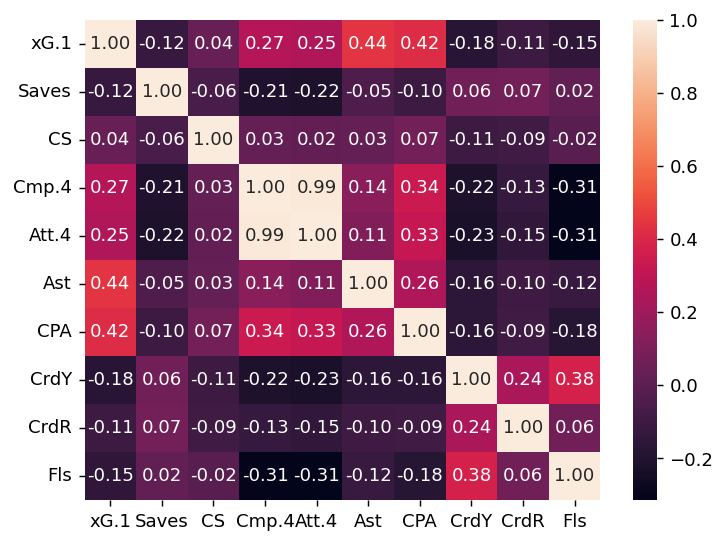

In [118]:
corr = dff.corr()

plt.figure(dpi=130)
sns.heatmap(dff.iloc[:,10:20].corr(), annot=True, fmt='.2f')
plt.show()


In [119]:
correlation_matrix = dff.corr().abs()
highly_correlated_mask = correlation_matrix > 0.8

columns_to_drop = set()
for i in range(len(highly_correlated_mask.columns)):
    for j in range(i+1, len(highly_correlated_mask.columns)):
        if highly_correlated_mask.iloc[i, j]:
            colname_i = highly_correlated_mask.columns[i]
            colname_j = highly_correlated_mask.columns[j]
            if colname_i not in columns_to_drop:
                columns_to_drop.add(colname_j)

dff.drop(columns=columns_to_drop, inplace=True)
dff.head()


C:\Users\moomad\AppData\Local\Temp\ipykernel_11788\3258642965.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff.drop(columns=columns_to_drop, inplace=True)


,Comp,Day,Venue,Team,Opponent,xGA,Poss,Attendance,Referee,SoT,...,O_In,O_Out,O_Str,O_Off,O_CPA,O_CrdY,O_CrdR,O_Fls,FTR,weight
0,24,0,1,0,0,0.3,77.0,30415.0,0,4.0,...,2.0,1.0,0.0,6.0,1.0,0.0,0.0,6.0,0.0,0.131153
1,24,1,0,0,1,0.6,64.0,49108.0,1,6.0,...,0.0,1.0,0.0,3.0,1.0,4.0,1.0,9.0,0.0,0.131579
2,24,0,1,0,2,0.5,70.0,10419.0,2,8.0,...,2.0,0.0,0.0,0.0,0.0,5.0,0.0,13.0,1.0,0.131817
3,24,0,0,0,3,0.7,66.0,54172.0,3,10.0,...,3.0,0.0,0.0,2.0,6.0,2.0,1.0,9.0,0.0,0.132486
4,4,2,1,0,4,0.3,71.0,43500.0,4,7.0,...,2.0,1.0,0.0,3.0,1.0,4.0,0.0,14.0,2.0,0.132679


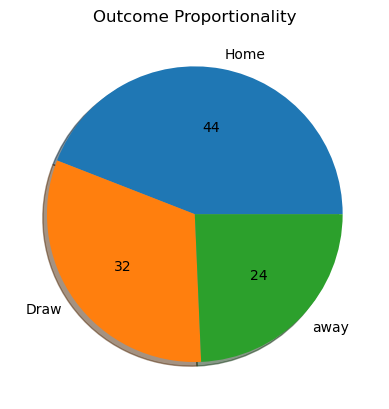

In [121]:
plt.pie(dff['FTR'].value_counts(),
        labels=['Home', 'Draw', 'away'],
        autopct='%.f', shadow=True)
plt.title('Outcome Proportionality')
plt.show()


In [123]:
dff['FTR'].value_counts()


FTR
0.0    13739
2.0     9851
1.0     7579
Name: count, dtype: int64

In [23]:
dff.to_csv('Preprocessed/Preprocessed_data.csv',
           index=False, mode='w', encoding='utf-8')
